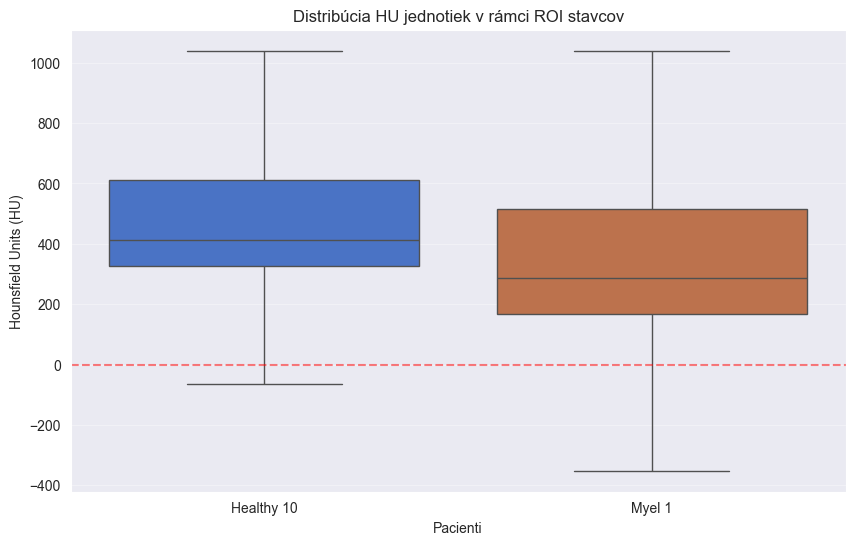

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

def get_roi_values(img_path, mask_path):
    # Načítanie CT obrazu a masky
    img = nib.load(img_path)
    mask = nib.load(mask_path)

    # Prevod na numpy polia
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    # Extrakcia HU hodnôt tam, kde je maska aktívna (napr. hodnota 1)
    roi_values = img_data[mask_data > 0]

    return roi_values

# Cesty k tvojim súborom (uprav si ich podľa reality)
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_spine_seg.nii.gz",
     "label": "Healthy 10"},
    {"img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
     "mask": r"E:\DATA_Myelomy\Myel_001\myel_001_spine_seg.nii.gz",
     "label": "Myel 1"}
]

all_values = []
labels = []

# Spracovanie dát
for p in data_config:
    values = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    labels.append(p['label'])

# Vizualizácia
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")

# Vytvorenie boxplotu
sns.boxplot(data=all_values, showfliers=False)

# Formátovanie grafu
plt.xticks(range(len(labels)), labels)
plt.title('Distribúcia HU jednotiek v rámci ROI stavcov')
plt.ylabel('Hounsfield Units (HU)')
plt.xlabel('Pacienti')

# Pridanie horizontálnej čiary pre nulu (voda), ak chceš referenciu
plt.axhline(color='red', linestyle='--', alpha=0.5)
plt.show()

Healthy percentile10 = -125.0
Healthy percentile10 = -131.0


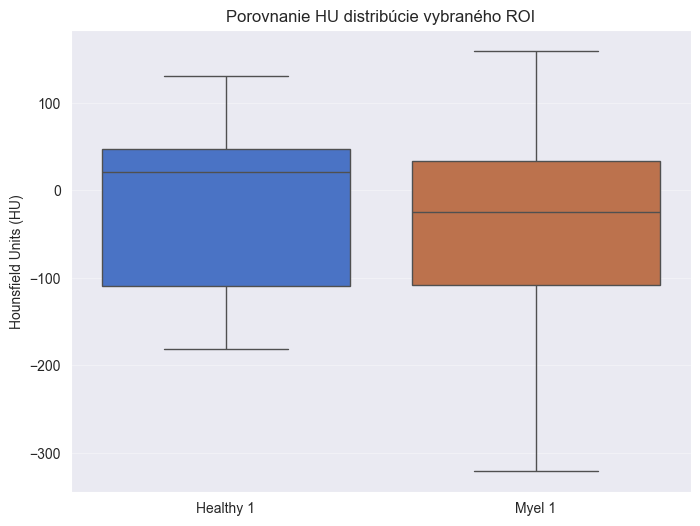

In [3]:
%matplotlib qt
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import time

def visualize_dual_sync(p1_cfg, p2_cfg):
    # 1. Načítanie oboch obrazov
    img1 = nib.load(p1_cfg['img']).get_fdata()
    img2 = nib.load(p2_cfg['img']).get_fdata()

    # Vytvorenie jednej figúry s dvoma podgrafmi (1 riadok, 2 stĺpce)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Nastavenie okna pre zobrazenie (Bone window pre spine)
    vmin, vmax = -200, 800

    # Určíme dĺžku animácie podľa toho, ktorý rozsah je kratší
    z_len1 = p1_cfg['z_range'][1] - p1_cfg['z_range'][0]
    z_len2 = p2_cfg['z_range'][1] - p2_cfg['z_range'][0]
    num_frames = min(z_len1, z_len2)

    plt.show(block=False)

    for i in range(num_frames):
        # Aktuálne indexy rezov pre každého pacienta
        z1 = p1_cfg['z_range'][0] + i
        z2 = p2_cfg['z_range'][0] + i

        # --- Pacient 1 (Vľavo) ---
        ax1.clear()
        ax1.imshow(img1[:, :, z1].T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        rect1 = plt.Rectangle((p1_cfg['x_range'][0], p1_cfg['y_range'][0]),
                              p1_cfg['x_range'][1]-p1_cfg['x_range'][0],
                              p1_cfg['y_range'][1]-p1_cfg['y_range'][0],
                              linewidth=2, edgecolor='green', facecolor='none')
        ax1.add_patch(rect1)
        ax1.set_title(f"{p1_cfg['label']} | Rez: {z1}")
        ax1.axis('on')

        # --- Pacient 2 (Vpravo) ---
        ax2.clear()
        ax2.imshow(img2[:, :, z2].T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        rect2 = plt.Rectangle((p2_cfg['x_range'][0], p2_cfg['y_range'][0]),
                              p2_cfg['x_range'][1]-p2_cfg['x_range'][0],
                              p2_cfg['y_range'][1]-p2_cfg['y_range'][0],
                              linewidth=2, edgecolor='red', facecolor='none')
        ax2.add_patch(rect2)
        ax2.set_title(f"{p2_cfg['label']} | Rez: {z2}")
        ax2.axis('on')

        # Prekreslenie spoločného okna
        fig.canvas.draw()
        fig.canvas.flush_events()
        time.sleep(0.05)

    plt.close(fig)

    # Extrakcia hodnôt pre boxplot (z celého 3D rozsahu)
    vals1 = img1[p1_cfg['x_range'][0]:p1_cfg['x_range'][1],
                 p1_cfg['y_range'][0]:p1_cfg['y_range'][1],
                 p1_cfg['z_range'][0]:p1_cfg['z_range'][1]].flatten()
    print(f"Healthy percentile10 = {np.percentile(vals1, 10)}")

    vals2 = img2[p2_cfg['x_range'][0]:p2_cfg['x_range'][1],
                 p2_cfg['y_range'][0]:p2_cfg['y_range'][1],
                 p2_cfg['z_range'][0]:p2_cfg['z_range'][1]].flatten()
    print(f"Healthy percentile10 = {np.percentile(vals2, 10)}")

    return vals1, vals2

# --- KONFIGURÁCIA ---
p1_config = {
    "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_001\healthy_001_konv.nii.gz",
    "label": "Healthy 1",
    "x_range": (25, 50), "y_range": (200, 225), "z_range": (100, 300)
}

p2_config = {
    "img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
    "label": "Myel 1",
    "x_range": (75, 100), "y_range": (200, 225), "z_range": (550, 750)
}

# Spustenie vizualizácie
v1, v2 = visualize_dual_sync(p1_config, p2_config)

# --- FINÁLNY BOXPLOT ---
import seaborn as sns
sns.set_style("darkgrid")
%matplotlib inline
plt.figure(figsize=(8, 6))
sns.boxplot(data=[v1, v2], showfliers=False)
plt.xticks([0, 1], [p1_config['label'], p2_config['label']])
plt.ylabel('Hounsfield Units (HU)')
plt.title('Porovnanie HU distribúcie vybraného ROI')
plt.show()

--- Zbieram dáta pre skupinu HEALTHY ---
Spracovávam Healthy_001...
Spracovávam Healthy_002...
Spracovávam Healthy_003...
Spracovávam Healthy_004...
Spracovávam Healthy_005...
Spracovávam Healthy_006...
Spracovávam Healthy_007...
Spracovávam Healthy_008...
Spracovávam Healthy_009...
Spracovávam Healthy_010...

--- Zbieram dáta pre skupinu MYELOMA ---
Spracovávam Myel_001...
Spracovávam Myel_002...
Spracovávam Myel_003...
Spracovávam Myel_004...
Spracovávam Myel_005...
Spracovávam Myel_006...
Spracovávam Myel_007...
Spracovávam Myel_008...
Spracovávam Myel_009...
Spracovávam Myel_010...


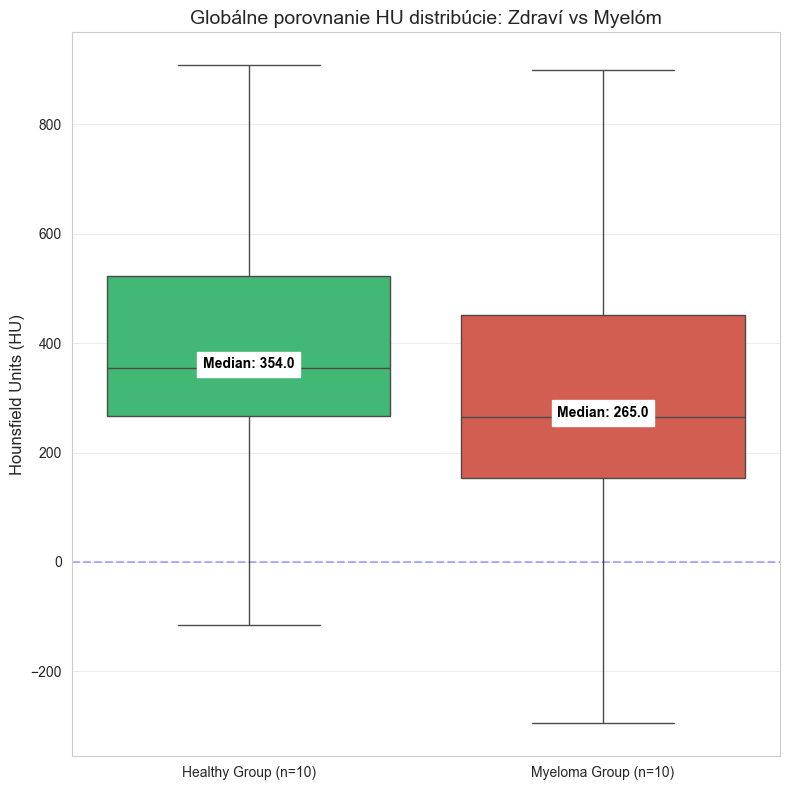

In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

def get_roi_values(img_path, mask_path):
    try:
        img = nib.load(img_path)
        mask = nib.load(mask_path)
        img_data = np.asarray(img.dataobj, dtype=np.int16)
        mask_data = np.asarray(mask.dataobj, dtype=np.uint8)
        return img_data[mask_data > 0]
    except Exception as e:
        print(f"Chyba pri načítaní {img_path}: {e}")
        return None

def collect_group_data(base_dir, limit=10):
    all_group_values = []
    subfolders = sorted([f.path for f in os.scandir(base_dir) if f.is_dir()])

    count = 0
    for folder in subfolders:
        if count >= limit:
            break

        img_files = glob(os.path.join(folder, "*_konv.nii.gz"))
        mask_files = glob(os.path.join(folder, "*_spine_seg.nii.gz"))

        if img_files and mask_files:
            print(f"Spracovávam {os.path.basename(folder)}...")
            vals = get_roi_values(img_files[0], mask_files[0])
            if vals is not None:
                all_group_values.append(vals)
                count += 1

    # Zlúčenie všetkých pacientov do jedného poľa
    if all_group_values:
        return np.concatenate(all_group_values)
    return np.array([])

# --- CESTY ---
path_healthy = r"E:\DATA_Healthy_and_Myelom\DATA_Healthy"
path_myelom = r"E:\DATA_Myelomy"

# Zber a spájanie dát
print("--- Zbieram dáta pre skupinu HEALTHY ---")
combined_healthy = collect_group_data(path_healthy)

print("\n--- Zbieram dáta pre skupinu MYELOMA ---")
combined_myeloma = collect_group_data(path_myelom)

# Príprava dát pre vizualizáciu
# Vytvoríme list dvoch polí
plot_data = [combined_healthy, combined_myeloma]
plot_labels = ["Healthy Group (n=10)", "Myeloma Group (n=10)"]

# --- VIZUALIZÁCIA ---
plt.figure(figsize=(8, 8))
sns.set_style("whitegrid")

# Vytvorenie boxplotu pre 2 skupiny
# showfliers=False je dôležité, lebo pri státisícoch voxelov by tam bolo milión bodiek
sns.boxplot(data=plot_data, showfliers=False, palette=["#2ecc71", "#e74c3c"])

plt.xticks(range(len(plot_labels)), plot_labels)
plt.title('Globálne porovnanie HU distribúcie: Zdraví vs Myelóm', fontsize=14)
plt.ylabel('Hounsfield Units (HU)', fontsize=12)

# Referenčná čiara pre vodu
plt.axhline(y=0, color='blue', linestyle='--', alpha=0.3, label='Voda (0 HU)')

# Pridanie mediánov ako text pre lepšiu čitateľnosť
for i, d in enumerate(plot_data):
    median_val = np.median(d)
    plt.text(i, median_val, f'Median: {median_val:.1f}',
             horizontalalignment='center', color='black', weight='bold', backgroundcolor='white')

plt.tight_layout()
plt.show()

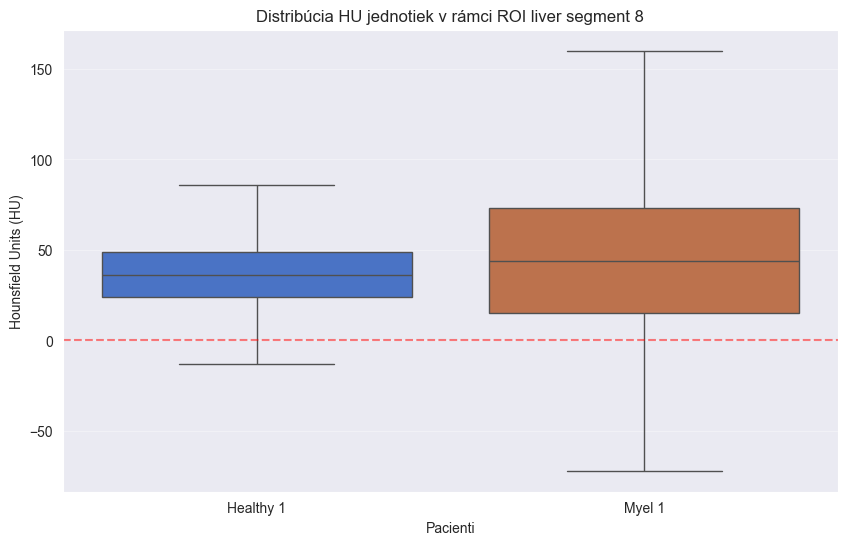

In [11]:
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

def get_roi_values(img_path, mask_path):
    # Načítanie CT obrazu a masky
    img = nib.load(img_path)
    mask = nib.load(mask_path)

    # Prevod na numpy polia
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    # Extrakcia HU hodnôt tam, kde je maska aktívna (napr. hodnota 1)
    roi_values = img_data[mask_data > 0]

    return roi_values

# Cesty k tvojim súborom (uprav si ich podľa reality)
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\liver_segment_8.nii.gz",
     "label": "Healthy 1"},
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\myel_001_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\liver_segment_8.nii.gz",
     "label": "Myel 1"}
]

all_values = []
labels = []

# Spracovanie dát
for p in data_config:
    values = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    labels.append(p['label'])

# Vizualizácia
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")

# Vytvorenie boxplotu
sns.boxplot(data=all_values, showfliers=False)

# Formátovanie grafu
plt.xticks(range(len(labels)), labels)
plt.title('Distribúcia HU jednotiek v rámci ROI liver segment 8')
plt.ylabel('Hounsfield Units (HU)')
plt.xlabel('Pacienti')

# Pridanie horizontálnej čiary pre nulu (voda), ak chceš referenciu
plt.axhline(color='red', linestyle='--', alpha=0.5)
plt.show()

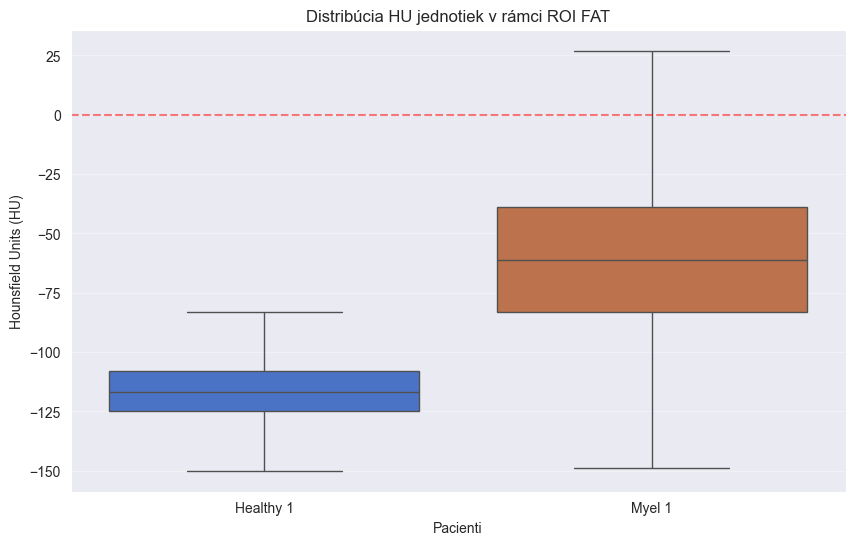

In [8]:
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

def get_roi_values(img_path, mask_path):
    # Načítanie CT obrazu a masky
    img = nib.load(img_path)
    mask = nib.load(mask_path)

    # Prevod na numpy polia
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    # Extrakcia HU hodnôt tam, kde je maska aktívna (napr. hodnota 1)
    roi_values = img_data[mask_data > 0]

    return roi_values

# Cesty k tvojim súborom (uprav si ich podľa reality)
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv_fat_segment.nii.gz",
     "label": "Healthy 1"},
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\myel_001_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\myel_001_konv_fat_segment.nii.gz",
     "label": "Myel 1"}
]

all_values = []
labels = []

# Spracovanie dát
for p in data_config:
    values = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    labels.append(p['label'])

# Vizualizácia
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")

# Vytvorenie boxplotu
sns.boxplot(data=all_values, showfliers=False)

# Formátovanie grafu
plt.xticks(range(len(labels)), labels)
plt.title('Distribúcia HU jednotiek v rámci ROI FAT')
plt.ylabel('Hounsfield Units (HU)')
plt.xlabel('Pacienti')

# Pridanie horizontálnej čiary pre nulu (voda), ak chceš referenciu
plt.axhline(color='red', linestyle='--', alpha=0.5)
plt.show()

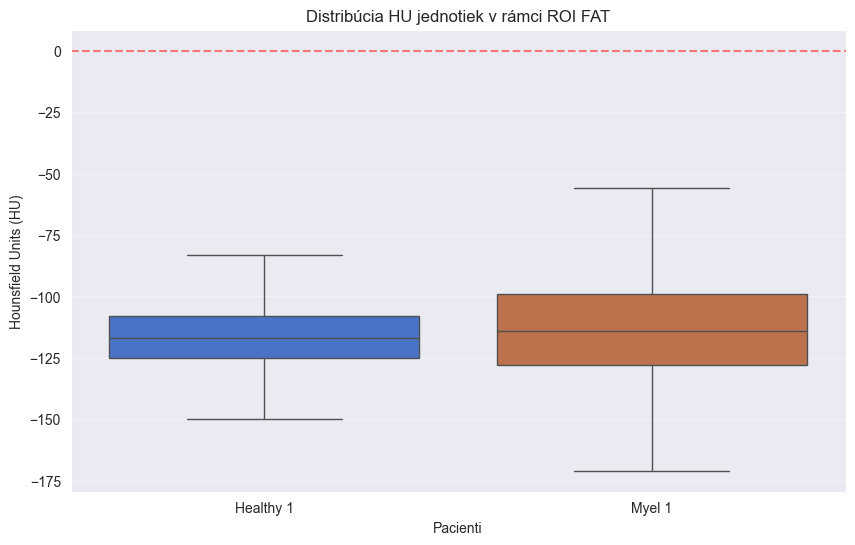

In [9]:
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

def get_roi_values(img_path, mask_path):
    # Načítanie CT obrazu a masky
    img = nib.load(img_path)
    mask = nib.load(mask_path)

    # Prevod na numpy polia
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    # Extrakcia HU hodnôt tam, kde je maska aktívna (napr. hodnota 1)
    roi_values = img_data[mask_data > 0]

    return roi_values

# Cesty k tvojim súborom (uprav si ich podľa reality)
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv_fat_segment.nii.gz",
     "label": "Healthy 1"},
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv_fat_segment.nii.gz",
     "label": "Myel 1"}
]

all_values = []
labels = []

# Spracovanie dát
for p in data_config:
    values = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    labels.append(p['label'])

# Vizualizácia
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")

# Vytvorenie boxplotu
sns.boxplot(data=all_values, showfliers=False)

# Formátovanie grafu
plt.xticks(range(len(labels)), labels)
plt.title('Distribúcia HU jednotiek v rámci ROI FAT')
plt.ylabel('Hounsfield Units (HU)')
plt.xlabel('Pacienti')

# Pridanie horizontálnej čiary pre nulu (voda), ak chceš referenciu
plt.axhline(color='red', linestyle='--', alpha=0.5)
plt.show()